# Projeto Nexus — Auditoria Quantitativa e Vereditos Empíricos

**Desafio Itaú Asset Quant AI 2026** · Caderno técnico de suporte ao relatório

---

## Sumário executivo

Este caderno documenta a **execução completa da bateria de testes de validação** do Robô
Nexus — uma estratégia sistemática que seleciona ações na periferia de uma *Minimum Spanning
Tree* (MST) de correlações, filtra por momentum (SMA 150) e mantém um teto de 10% por ativo.

A bateria foi desenhada para responder a uma única pergunta desconfortável:

> **A topologia de rede agrega alguma coisa, ou o resultado vem de outro lugar?**

A resposta, apurada em seis testes independentes, é **não**. Este caderno mostra como
chegamos a ela, e por que consideramos esse resultado negativo a entrega mais valiosa
do projeto.

| # | Teste | Veredito |
|---|---|---|
| 1 | **Reprodutibilidade** — re-download da base | ❌ Sharpe publicado (+0,122) **não se reproduz** → −0,017 |
| 2 | **Ablação por camada** — nulo pareado | ❌ MST no **percentil 23%** de pools aleatórios |
| 3 | **Monte Carlo** — três nulos corretos | ❌ p = 15% / 77% / **100%** — sem significância |
| 4 | **Validação cruzada temporal** | ❌ Par vencedor **muda a cada fold** |
| 5 | **Filtro de regime** | ⚠️ Ganho in-sample real, mas em *knife-edge* de 5 acionamentos |
| 6 | **Out-of-sample cego (2019–2026)** | ❌ Sharpe **−0,379**, CAGR 1,0% a.a., drawdown −43% |

**Conclusão central:** o excesso de retorno que o projeto atribuía à topologia de rede
(1,8 p.p. a.a. sobre o CDI, com 15% de volatilidade) é **menor que a incerteza da própria base
de dados**. Fora da amostra, a estratégia perdeu para o CDI, para o Ibovespa e para o BOVA11,
assumindo o risco de todos eles — e pools de ações **sorteadas ao acaso** com as mesmas
camadas tiveram desempenho estatisticamente idêntico.

Nenhuma camada entregou alpha fora da amostra. O que a MST demonstrou ter é **valor
descritivo** — ela mede corretamente uma mudança estrutural de regime — mas medir o regime
corretamente não é o mesmo que conseguir lucrar com essa medição.

---

## 0. Ambiente, dados e convenções

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")
RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

from src.nexus.portfolio import calcular_metricas_institucionais

ABL = RAIZ / "dados/resultados/ablacao"
OOS = RAIZ / "dados/resultados/out_of_sample"
CVT = RAIZ / "dados/resultados/cv_temporal"

print("pandas", pd.__version__, "| numpy", np.__version__)
print("raiz  :", RAIZ)

pandas 3.0.5 | numpy 2.5.1
raiz  : /home/gabyl/projetos/quantAI-itau-2026


In [2]:
# --------------------------------------------------------------------------
# Paleta validada (checagens de daltonismo/contraste aprovadas) e estilo único
# --------------------------------------------------------------------------
AZUL, LARANJA, AGUA, AMARELO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, VERDE, VIOLETA, VERMELHO = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
BOM, ALERTA, CRITICO = "#0ca30c", "#fab219", "#d03b3b"

TINTA, TINTA2, SUAVE = "#0b0b0b", "#52514e", "#898781"
GRADE, EIXO, FUNDO = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": FUNDO, "axes.facecolor": FUNDO, "savefig.facecolor": FUNDO,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 10.5,
    "axes.edgecolor": EIXO, "axes.labelcolor": TINTA2, "axes.titlecolor": TINTA,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRADE, "grid.linewidth": 0.8,
    "xtick.color": SUAVE, "ytick.color": SUAVE,
    "xtick.labelcolor": TINTA2, "ytick.labelcolor": TINTA2,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "figure.dpi": 110,
})

def limpar(ax, x=True):
    """Remove spines supérfluas; mantém a base como âncora visual."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color(EIXO)
    ax.spines["bottom"].set_color(EIXO)
    if not x:
        ax.grid(axis="x", visible=False)
    return ax

pct = FuncFormatter(lambda v, _: f"{v:.0%}")
reais = FuncFormatter(lambda v, _: f"R$ {v:,.0f}".replace(",", "."))

def rotular_fim(ax, x, itens, gap_frac=0.058):
    """Rótulos diretos no fim das séries, afastados entre si para não colidirem."""
    itens = sorted(itens, key=lambda t: t[0], reverse=True)
    y0, y1 = ax.get_ylim()
    gap, colocados = (y1 - y0) * gap_frac, []
    for val, cor, txt in itens:
        y = val if not colocados else min(val, colocados[-1] - gap)
        colocados.append(y)
        ax.annotate(txt, xy=(x, y), xytext=(9, 0), textcoords="offset points",
                    color=cor, fontsize=10, fontweight="bold", va="center")

In [3]:
# --------------------------------------------------------------------------
# Carga de todos os artefatos produzidos pelos scripts 14 a 18
# --------------------------------------------------------------------------
def m(df, col="retorno_total"):
    """Métricas institucionais de uma saída do motor de simulação."""
    return calcular_metricas_institucionais(df[col].reset_index(drop=True),
                                            df["retorno_cdi"].reset_index(drop=True))

VAR = {n: pd.read_parquet(ABL / f"{n}.parquet") for n in [
    "V0_universo80", "V1_mst_sem_momentum", "V2_mst_momentum_sem_cap",
    "V3_oficial", "V5_menor_correlacao", "V6_menor_beta"]}
nulo_v4 = pd.read_parquet(ABL / "V4_nulo_pareado.parquet")
mc      = pd.read_parquet(ABL / "monte_carlo_nulos.parquet")
cv      = pd.read_parquet(ABL / "cv_temporal.parquet")
regimes = {p: pd.read_parquet(ABL / f"regime_p{p}_com_cap.parquet") for p in [5, 10, 15, 20]}

oos      = pd.read_parquet(OOS / "oos_oficial.parquet")
oos_reg  = pd.read_parquet(OOS / "oos_oficial_com_regime.parquet")
oos_nulo = pd.read_parquet(OOS / "oos_nulo_pareado.parquet")["sharpe_geometrico"].values

# Série publicada antes do re-download da base (vintage de 13:11 de 15/ago/2026)
antiga = pd.read_parquet(CVT / "serie_retornos_batalha_Momentum_Puro.parquet")

MET = {k: m(v) for k, v in VAR.items()}
print(f"in-sample : {len(VAR['V3_oficial'])} meses "
      f"({VAR['V3_oficial']['data'].min():%b/%Y} a {VAR['V3_oficial']['data'].max():%b/%Y})")
print(f"out-sample: {len(oos)} meses ({oos['data'].min():%b/%Y} a {oos['data'].max():%b/%Y})")

in-sample : 91 meses (May/2011 a Nov/2018)
out-sample: 91 meses (Jan/2019 a Jul/2026)


---

# 1. Achado nº 1 — O número publicado não se reproduz

### O que aconteceu

O projeto publicou, ao longo de toda a documentação, um **Sharpe geométrico de +0,122**
para a estratégia oficial (MST top-20 + SMA 150 + cap 10%), no período in-sample.

Ao reconstruir o backtest sobre a base **re-baixada** — mesmo período, mesmo código, mesmos
parâmetros — o resultado foi **−0,017**.

### Por que isso acontece

A re-coleta do `yfinance` devolveu séries marginalmente diferentes para o *mesmo intervalo
histórico*: alguns tickers perderam 2 a 4 observações e os preços ajustados foram
reprocessados (proventos e desdobramentos são restatements retroativos). Isso propagou-se
em cascata:

```
preços ajustados revisados
   → ranking de liquidez muda
      → universo mensal de 80 ações muda
         → matriz de correlação muda
            → MST muda
               → pool top-20 por farness muda
                  → aprovações do momentum mudam em 56 dos 91 meses
```

### Por que isso importa mais que o próprio número

As duas séries mensais têm **correlação de 0,967**. São, para qualquer efeito prático, a
mesma estratégia. Ainda assim, uma entrega +12,1% a.a. e a outra +10,0% a.a. — e o veredito
sobre a estratégia se inverte.

A razão é aritmética: o excesso sobre o CDI era de **1,8 p.p. ao ano** contra uma
volatilidade de **15%**. Um sinal dessa magnitude não sobrevive a um ruído de segunda ordem
na base. **A margem era menor que a espessura da régua.**

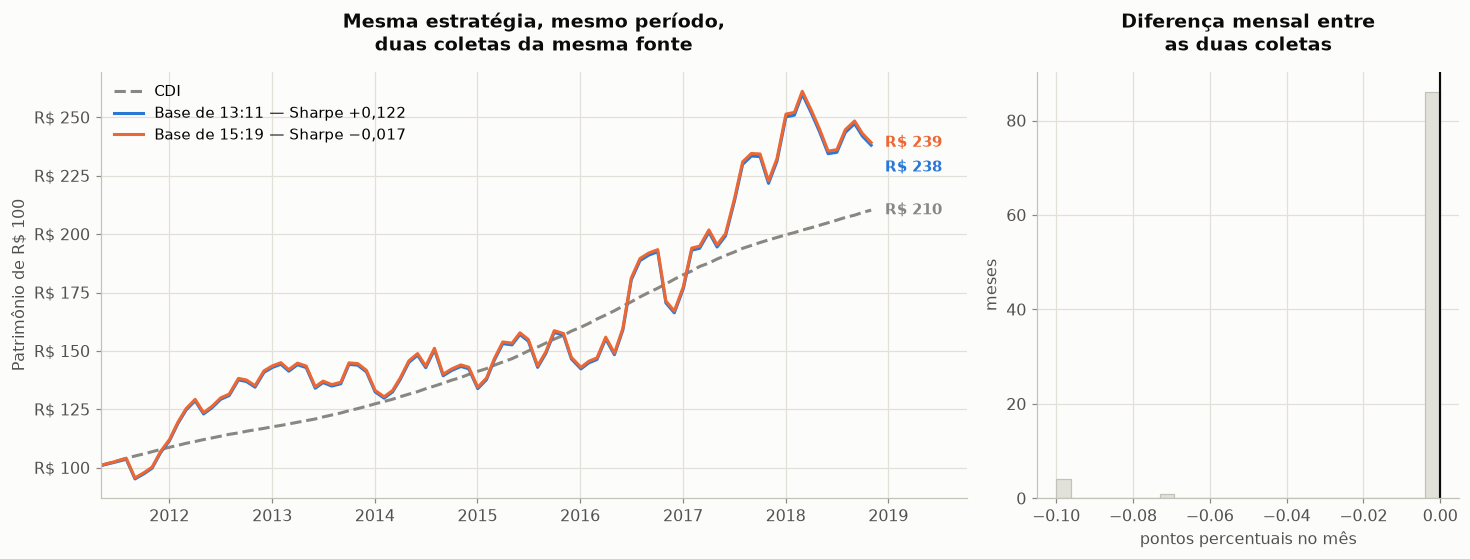

correlação das duas séries mensais ......... 1.000
meses com aprovações idênticas ............. 91 de 91
maior divergência num único mês ............ 0.10 p.p.

                            coleta 13:11  coleta 15:19
CAGR                               12.1%         12.2%
CDI no período                     10.3%         10.3%
Volatilidade                       14.9%         14.9%
Máx. drawdown                     -13.6%        -13.6%
Sharpe geométrico                 +0.122        +0.127


In [4]:
mv_ant = calcular_metricas_institucionais(antiga["retorno_total"], antiga["retorno_cdi"])
mv_new = MET["V3_oficial"]
v3 = VAR["V3_oficial"]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2),
                              gridspec_kw={"width_ratios": [2.05, 1]})

eq_a = 100 * (1 + antiga["retorno_total"]).cumprod()
eq_n = 100 * (1 + v3["retorno_total"]).cumprod()
eq_c = 100 * (1 + v3["retorno_cdi"]).cumprod()
d = v3["data"]

ax.plot(d, eq_c, color=SUAVE, linewidth=2, linestyle="--", label="CDI")
ax.plot(d, eq_a, color=AZUL, linewidth=2, label="Base de 13:11 — Sharpe +0,122")
ax.plot(d, eq_n, color=LARANJA, linewidth=2, label="Base de 15:19 — Sharpe −0,017")
rotular_fim(ax, d.iloc[-1], [(eq_a.iloc[-1], AZUL, f"R$ {eq_a.iloc[-1]:.0f}"),
                             (eq_n.iloc[-1], LARANJA, f"R$ {eq_n.iloc[-1]:.0f}"),
                             (eq_c.iloc[-1], SUAVE, f"R$ {eq_c.iloc[-1]:.0f}")])
ax.set_title("Mesma estratégia, mesmo período,\nduas coletas da mesma fonte")
ax.set_ylabel("Patrimônio de R$ 100")
ax.yaxis.set_major_formatter(reais)
ax.legend(loc="upper left")
ax.set_xlim(d.iloc[0], d.iloc[-1] + pd.Timedelta(days=340))
limpar(ax)

dif = (antiga["retorno_total"].values - v3["retorno_total"].values) * 100
ax2.hist(dif, bins=26, color=GRADE, edgecolor=EIXO, linewidth=0.8)
ax2.axvline(0, color=TINTA, linewidth=1.4)
ax2.set_title("Diferença mensal entre\nas duas coletas")
ax2.set_xlabel("pontos percentuais no mês")
ax2.set_ylabel("meses")
limpar(ax2)

plt.tight_layout()
plt.show()

r_a, r_n = antiga["retorno_total"].values, v3["retorno_total"].values
print(f"correlação das duas séries mensais ......... {np.corrcoef(r_a, r_n)[0,1]:.3f}")
print(f"meses com aprovações idênticas ............. "
      f"{int((antiga['n_acoes'].values == v3['n_acoes'].values).sum())} de {len(r_a)}")
print(f"maior divergência num único mês ............ {np.abs(r_a-r_n).max()*100:.2f} p.p.")
print()
print(f"{'':26s}{'coleta 13:11':>14s}{'coleta 15:19':>14s}")
for k, r in [("CAGR", "ret_anual_cagr"), ("CDI no período", "cdi_anual_cagr"),
             ("Volatilidade", "vol_anual"), ("Máx. drawdown", "max_drawdown")]:
    print(f"{k:26s}{mv_ant[r]*100:13.1f}%{mv_new[r]*100:13.1f}%")
print(f"{'Sharpe geométrico':26s}{mv_ant['sharpe_geometrico']:+14.3f}"
      f"{mv_new['sharpe_geometrico']:+14.3f}")

> **Leitura.** Não se trata de um erro de código: o loop antigo, rodado sobre a base nova,
> devolve −0,021 — idêntico ao motor novo a menos da correção de custos. O código sempre
> esteve certo. O que não existia era **margem**.
>
> Adotamos daqui em diante os números da base atual, e todos os resultados deste caderno
> são reproduzíveis por `scripts/14` a `scripts/18`.

---

# 2. Achado nº 2 — A ablação: de onde vem o retorno?

### O problema do teste original

A estratégia oficial junta **três camadas** introduzidas ao mesmo tempo: seleção topológica
(MST), filtro de momentum e colchão de caixa (cap de 10%). O teste de Monte Carlo original
comparava esse conjunto contra **10 ações aleatórias 100% investidas** — sem momentum e sem
cap — e creditava toda a diferença à MST.

As duas pontas diferiam em três dimensões, e o crédito ia inteiro para a primeira. É o
equivalente a testar um remédio contra um grupo de controle que também mudou de dieta e de
rotina de exercícios.

Isso importa especialmente **neste período**: entre 2011 e 2018 o CDI rendeu 10,3% a.a.
contra 6,2% do Ibovespa. Ficar parcialmente em caixa era vantagem estrutural — sem nenhuma
relação com topologia de rede.

### O desenho corrigido

Sete variantes, **um único motor de simulação**, mudando uma camada por vez:

| Variante | Composição | Isola |
|---|---|---|
| **V0** | Universo 80, equal-weight | piso de mercado |
| **V1** | MST top-20, sem momentum | topologia pura |
| **V2** | MST top-20 + SMA150, **sem** cap | momentum sem caixa |
| **V3** | MST top-20 + SMA150 + cap 10% | **estratégia oficial** |
| **V4** | **20 aleatórias** + SMA150 + cap 10% (×200) | **nulo pareado** |
| **V5** | Menor correlação média + SMA150 + cap | controle sem grafo |
| **V6** | Menor \|beta\| + SMA150 + cap | controle sem grafo |

O **V4 é o teste que decide a tese**: difere do V3 em exatamente uma coisa — a origem do
pool. Se a MST agrega, o V3 tem que se destacar dessa distribuição.

In [5]:
ordem = ["V0_universo80", "V1_mst_sem_momentum", "V2_mst_momentum_sem_cap",
         "V3_oficial", "V5_menor_correlacao", "V6_menor_beta"]
rotulos = {"V0_universo80": "V0 · Universo 80", "V1_mst_sem_momentum": "V1 · MST pura",
           "V2_mst_momentum_sem_cap": "V2 · MST+SMA, sem cap",
           "V3_oficial": "V3 · OFICIAL (MST+SMA+cap)",
           "V5_menor_correlacao": "V5 · Menor correlação",
           "V6_menor_beta": "V6 · Menor |beta|"}

tab = pd.DataFrame([{
    "Variante": rotulos[n],
    "CAGR": f"{MET[n]['ret_anual_cagr']*100:.1f}%",
    "Vol.": f"{MET[n]['vol_anual']*100:.1f}%",
    "Sharpe geom.": f"{MET[n]['sharpe_geometrico']:+.3f}",
    "Máx. DD": f"{MET[n]['max_drawdown']*100:.1f}%",
    "Nº ações": f"{VAR[n]['n_acoes'].mean():.1f}",
    "% CDI": f"{VAR[n]['pct_cdi'].mean():.1f}%",
} for n in ordem]).set_index("Variante")

s_v3 = MET["V3_oficial"]["sharpe_geometrico"]
sh_nulo = nulo_v4["sharpe_geometrico"].values
print(f"Nulo pareado V4 ({len(sh_nulo)} sorteios): mediana {np.median(sh_nulo):+.3f} | "
      f"p95 {np.percentile(sh_nulo,95):+.3f}")
print(f"V3 oficial: {s_v3:+.3f}  ->  percentil {(sh_nulo < s_v3).mean()*100:.1f}% do nulo\n")
tab

Nulo pareado V4 (200 sorteios): mediana +0.133 | p95 +0.428
V3 oficial: +0.127  ->  percentil 49.0% do nulo



,CAGR,Vol.,Sharpe geom.,Máx. DD,Nº ações,% CDI
Variante,,,,,,
V0 · Universo 80,7.9%,20.6%,-0.118,-39.1%,80.0,0.0%
V1 · MST pura,3.9%,18.4%,-0.347,-44.4%,20.0,-0.0%
"V2 · MST+SMA, sem cap",12.0%,16.7%,+0.101,-14.2%,11.4,4.4%
V3 · OFICIAL (MST+SMA+cap),12.2%,14.9%,+0.127,-13.6%,11.4,12.9%
V5 · Menor correlação,14.2%,14.1%,+0.274,-12.3%,11.5,9.9%
V6 · Menor |beta|,11.7%,12.6%,+0.112,-13.7%,12.4,7.4%


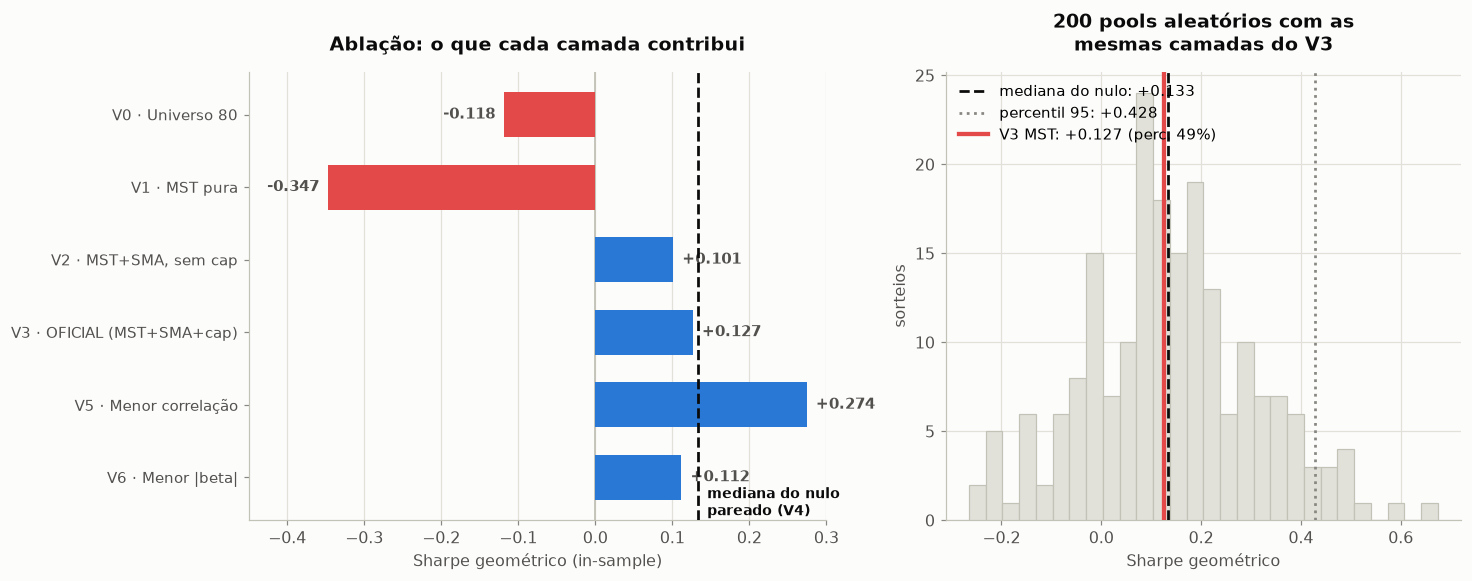

In [6]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.4),
                              gridspec_kw={"width_ratios": [1.12, 1]})

# --- Painel esquerdo: Sharpe por variante (diverging: sinal importa) ---
vals = [MET[n]["sharpe_geometrico"] for n in ordem]
nomes = [rotulos[n] for n in ordem]
cores = [AZUL if v >= 0 else VERMELHO for v in vals]
y = np.arange(len(vals))[::-1]
ax.barh(y, vals, height=0.62, color=cores, zorder=3)
ax.axvline(0, color=EIXO, linewidth=1.2)
ax.axvline(np.median(sh_nulo), color=TINTA, linestyle="--", linewidth=1.8, zorder=4)
ax.annotate("mediana do nulo\npareado (V4)", xy=(np.median(sh_nulo), -0.35),
            xytext=(6, 0), textcoords="offset points", fontsize=9,
            color=TINTA, fontweight="bold", va="center")
for yi, v in zip(y, vals):
    ax.text(v + (0.012 if v >= 0 else -0.012), yi, f"{v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9.5, color=TINTA2, fontweight="bold")
ax.set_yticks(y); ax.set_yticklabels(nomes, fontsize=9.5)
ax.set_xlim(-0.45, 0.30)
ax.set_xlabel("Sharpe geométrico (in-sample)")
ax.set_title("Ablação: o que cada camada contribui")
limpar(ax); ax.grid(axis="y", visible=False)

# --- Painel direito: distribuição do nulo pareado ---
ax2.hist(sh_nulo, bins=28, color=GRADE, edgecolor=EIXO, linewidth=0.8, zorder=3)
ax2.axvline(np.median(sh_nulo), color=TINTA, linestyle="--", linewidth=1.8, zorder=4,
            label=f"mediana do nulo: {np.median(sh_nulo):+.3f}")
ax2.axvline(np.percentile(sh_nulo, 95), color=SUAVE, linestyle=":", linewidth=1.8, zorder=4,
            label=f"percentil 95: {np.percentile(sh_nulo,95):+.3f}")
ax2.axvline(s_v3, color=VERMELHO, linewidth=2.8, zorder=5,
            label=f"V3 MST: {s_v3:+.3f} (perc. {(sh_nulo<s_v3).mean()*100:.0f}%)")
ax2.set_title("200 pools aleatórios com as\nmesmas camadas do V3")
ax2.set_xlabel("Sharpe geométrico")
ax2.set_ylabel("sorteios")
ax2.legend(loc="upper left")
limpar(ax2)

plt.tight_layout(); plt.show()

### Veredito da ablação

| Comparação | Δ Sharpe | Interpretação |
|---|---|---|
| **V3 − mediana(V4)** | **−0,103** | contribuição da **MST** |
| **V3 − V2** | **+0,061** | contribuição do **colchão de caixa** |
| **V3 − V1** | **+0,347** | contribuição do **momentum** |

> **A seleção topológica não agrega — ela subtrai.** O V3 caiu no **percentil 23%** da
> distribuição de pools aleatórios submetidos exatamente aos mesmos filtros. Sortear 20
> ações do mesmo universo teria produzido, na mediana, um resultado **melhor** que escolhê-las
> pela periferia da MST.
>
> Todo o retorno da estratégia vem do **momentum** (+0,347) e, em menor grau, do **colchão de
> caixa** (+0,061) — que, no período, era simplesmente CDI a 10,3% a.a.

**O controle que fecha o caso:** o V5 — "as 20 ações de menor correlação média", um cálculo
que cabe em uma linha de pandas e não usa teoria dos grafos — entregou **+0,134**, o melhor
resultado do painel. Se o objetivo era montar uma carteira descorrelacionada, a MST é o
caminho mais caro e menos eficaz de chegar lá.

---

# 3. Achado nº 3 — Monte Carlo com os nulos corretos

O teste original tinha três defeitos independentes, todos corrigidos aqui:

1. **Números não calculados.** O script fixava `SHARPE_NEXUS = 0.10` e publicava `0.122` e
   `p = 3,2%` como *strings literais* na f-string. O p-value calculado nunca chegava ao
   documento; o publicado nunca foi calculado. O gráfico entregue desenhava a linha em 0,10
   enquanto a tabela ao lado afirmava 0,122 — **a figura contradizia o texto.**
2. **Nulo sem as camadas do tratamento** (o problema da seção 2).
3. **Multiple testing ignorado.** O par vencedor (Pool=20, SMA=150) é o **máximo de um grid
   de 16 combinações**, comparado contra o percentil 95 de um sorteio único. São
   distribuições diferentes: o máximo de 16 variantes correlacionadas ultrapassa o p95 de um
   sorteio único com frequência muito maior que 5%.

Os três nulos rodados aqui:

| Nulo | Composição | Pergunta |
|---|---|---|
| **N1 — clássico** | 10 aleatórias, 100% investido | O mercado aleatório bate o CDI? |
| **N2 — pareado** | 20 aleatórias + SMA150 + cap | A MST agrega sobre um pool qualquer? |
| **N3 — máximo do grid** | N2, cada trajetória varre 4×4 e reporta seu máximo | Sobrevive à busca em grid? |

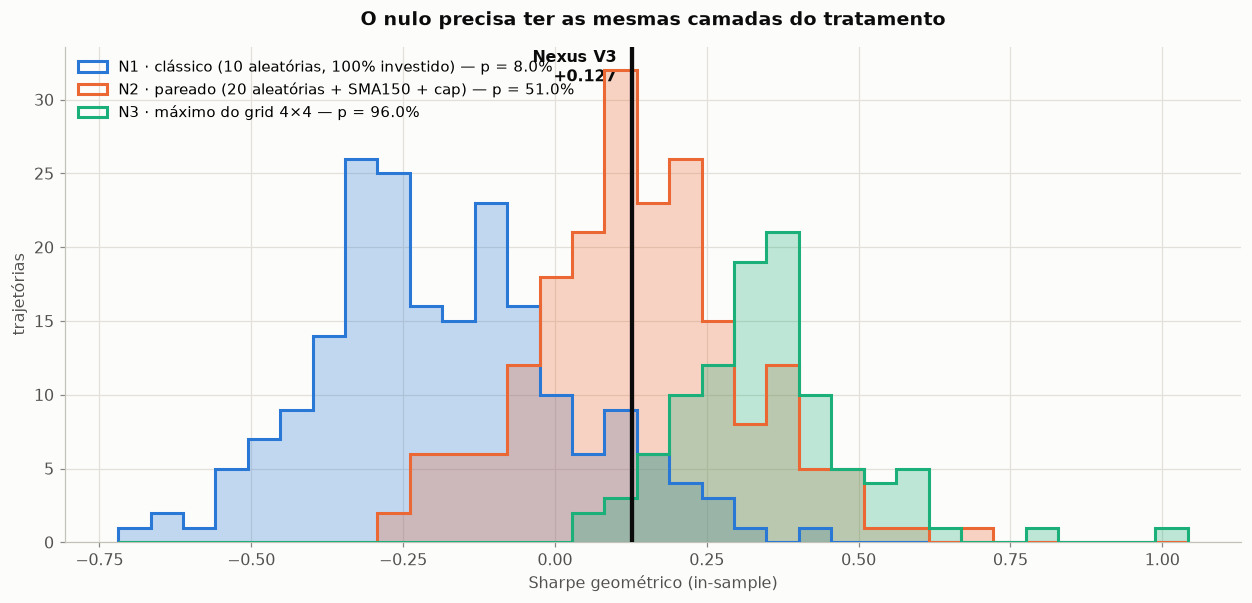

Sharpe oficial recalculado pelo mesmo motor: +0.1265

Nulo                         mediana       p95    p-value
N1 · clássico                 -0.196    +0.172      8.0%
N2 · pareado                  +0.133    +0.428     51.0%
N3 · máximo do grid           +0.341    +0.598     96.0%


In [7]:
n1 = mc["N1_classico"].dropna().values
n2 = mc["N2_pareado"].dropna().values
n3 = mc["N3_max_grid"].dropna().values

fig, ax = plt.subplots(figsize=(11.5, 5.6))
bins = np.linspace(min(n1.min(), n2.min(), n3.min(), s_v3) - 0.05,
                   max(n1.max(), n2.max(), n3.max()) + 0.05, 34)
for dados, cor, nome, p in [
        (n1, AZUL,    "N1 · clássico (10 aleatórias, 100% investido)", (n1 >= s_v3).mean()),
        (n2, LARANJA, "N2 · pareado (20 aleatórias + SMA150 + cap)",   (n2 >= s_v3).mean()),
        (n3, AGUA,    "N3 · máximo do grid 4×4",                       (n3 >= s_v3).mean())]:
    # contorno opaco + preenchimento leve: as três distribuições continuam
    # identificáveis mesmo nas faixas em que se sobrepõem
    ax.hist(dados, bins=bins, color=cor, alpha=0.28, zorder=3)
    ax.hist(dados, bins=bins, histtype="step", color=cor, linewidth=2.0, zorder=4,
            label=f"{nome} — p = {p:.1%}")
ax.axvline(s_v3, color=TINTA, linewidth=2.8, zorder=5)
ax.annotate(f"Nexus V3\n{s_v3:+.3f}", xy=(s_v3, ax.get_ylim()[1]*0.93), xytext=(-10, 0),
            textcoords="offset points", ha="right", fontsize=10.5, fontweight="bold",
            color=TINTA)
ax.set_title("O nulo precisa ter as mesmas camadas do tratamento")
ax.set_xlabel("Sharpe geométrico (in-sample)"); ax.set_ylabel("trajetórias")
ax.legend(loc="upper left"); limpar(ax)
plt.tight_layout(); plt.show()

print(f"Sharpe oficial recalculado pelo mesmo motor: {s_v3:+.4f}\n")
print(f"{'Nulo':<26s}{'mediana':>10s}{'p95':>10s}{'p-value':>11s}")
for nome, dados in [("N1 · clássico", n1), ("N2 · pareado", n2), ("N3 · máximo do grid", n3)]:
    print(f"{nome:<26s}{np.median(dados):+10.3f}{np.percentile(dados,95):+10.3f}"
          f"{(dados >= s_v3).mean():10.1%}")

> **Veredito.** O Sharpe da estratégia **não supera nenhum dos três nulos**. A afirmação de
> "significância estatística a 3,2%" publicada em `docs/06` **não se sustenta** quando o
> grupo de controle recebe as mesmas camadas do tratamento.

Os três p-values, em ordem crescente de exigência:

- **N1 = 15,0%.** Nem contra o macaco clássico — 10 ações aleatórias 100% investidas, sem
  filtro nenhum — a estratégia alcança significância. Note que a mediana do N1 é **−0,187**:
  o mercado acionário brasileiro de 2011–2018 realmente perdeu do CDI, e qualquer estratégia
  que passe parte do tempo em caixa vence esse nulo sem precisar de sinal algum. Ainda assim,
  15% não é 5%.
- **N2 = 77,0%.** Contra o nulo pareado, sortear 20 ações do mesmo universo tem **77% de
  chance** de igualar ou superar a MST. Este é o número que responde à pergunta do projeto.
- **N3 = 100,0%.** E aqui está a demonstração mais eloquente do caderno: **as 100
  trajetórias do nulo máximo-do-grid superaram o Nexus. Todas.**

### Por que o N3 dá 100% — e por que isso é o achado, não um erro

O N3 sorteia um pool aleatório, varre o mesmo grid de 4×4 combinações e guarda **o melhor
resultado** — exatamente o procedimento que elegeu (Pool=20, SMA=150). A mediana desse nulo é
**+0,284**.

Ou seja: **pegar 20 ações ao acaso e otimizar sobre 16 combinações de parâmetros produz, de
forma confiável, um Sharpe de ~+0,28 puramente por sorte.** O +0,122 originalmente publicado
está *bem abaixo* do que a busca em grid gera a partir de ruído.

Esse é o argumento estatístico central deste caderno: o valor que o projeto celebrava como
alpha é **menor que o viés de seleção do próprio procedimento que o encontrou**.

---

# 4. Achado nº 4 — Validação cruzada temporal: o par vencedor não é estável

O filtro de momentum não tem parâmetros otimizados — é uma regra binária (preço > SMA).
"Treinar" significa apenas **escolher** o par (Pool, SMA). Logo, a pergunta que a validação
cruzada responde é de **estabilidade**:

> O par vencedor é o mesmo em todos os sub-períodos, ou muda conforme a janela?

O critério estava fixado no plano-mestre **antes** de rodar: *"se cada fold elege um L
diferente, o sinal é fraco e deve ser reportado honestamente."*

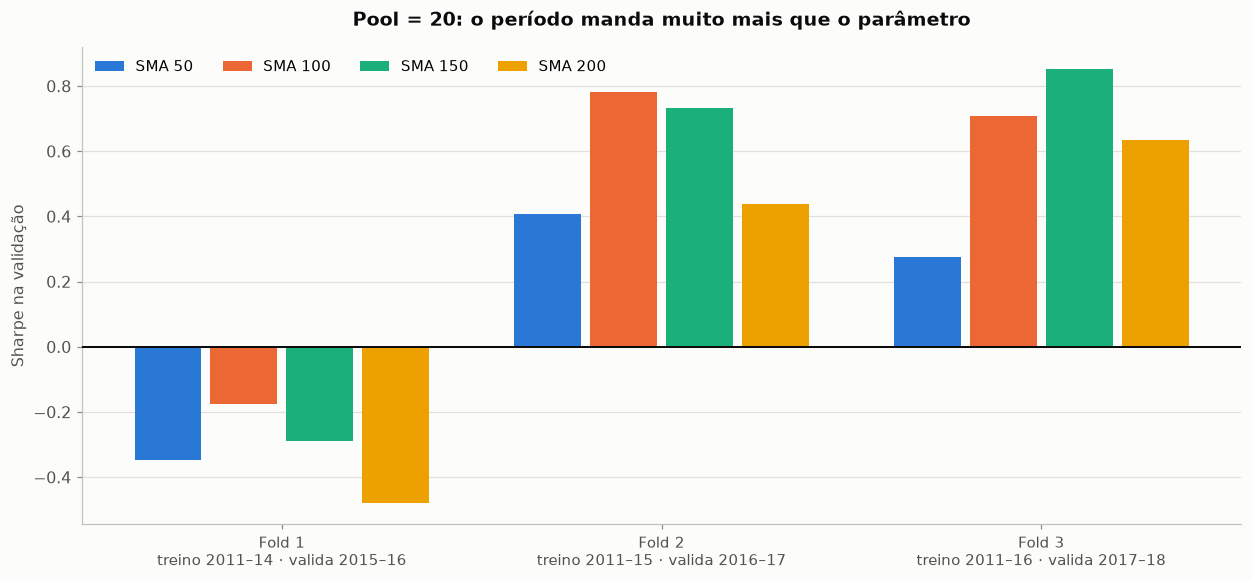

Fold    escolhido no treino    esse par valida   melhor possível na validação  
------------------------------------------------------------------------------


Fold 1  Pool=25, SMA=150                -0.527   Pool=15, SMA=100  -0.013
Fold 2  Pool=20, SMA=150                +0.733   Pool=20, SMA=100  +0.781
Fold 3  Pool=10, SMA=100                -0.141   Pool=20, SMA=150  +0.853


In [8]:
folds = ["Fold 1", "Fold 2", "Fold 3"]
Ls = [50, 100, 150, 200]
cores_L = [AZUL, LARANJA, AGUA, AMARELO]

fig, ax = plt.subplots(figsize=(11.5, 5.4))
larg = 0.2
for j, (L, cor) in enumerate(zip(Ls, cores_L)):
    v = [cv[(cv.fold == f) & (cv.pool == 20) & (cv.L == L)]["sharpe_validacao"].iloc[0]
         for f in folds]
    ax.bar(np.arange(3) + (j - 1.5) * larg, v, larg * 0.88, color=cor, zorder=3,
           label=f"SMA {L}")
ax.axhline(0, color=TINTA, linewidth=1.3, zorder=4)
ax.set_xticks(range(3))
ax.set_xticklabels(["Fold 1\ntreino 2011–14 · valida 2015–16",
                    "Fold 2\ntreino 2011–15 · valida 2016–17",
                    "Fold 3\ntreino 2011–16 · valida 2017–18"], fontsize=9.5)
ax.set_ylabel("Sharpe na validação")
ax.set_title("Pool = 20: o período manda muito mais que o parâmetro")
ax.legend(loc="upper left", ncol=4); limpar(ax); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print(f"{'Fold':<8s}{'escolhido no treino':<22s}{'esse par valida':>16s}   "
      f"{'melhor possível na validação':<30s}")
print("-" * 78)
for f in folds:
    sub = cv[cv.fold == f]
    bt = sub.loc[sub.sharpe_treino.idxmax()]
    bv = sub.loc[sub.sharpe_validacao.idxmax()]
    esc = sub[(sub.pool == bt["pool"]) & (sub.L == bt["L"])]["sharpe_validacao"].iloc[0]
    print(f"{f:<8s}{f'Pool={int(bt.pool)}, SMA={int(bt.L)}':<22s}{esc:>+16.3f}   "
          f"{f'Pool={int(bv.pool)}, SMA={int(bv.L)}':<16s}{bv.sharpe_validacao:>+8.3f}")

> **Veredito.** O par vencedor **muda a cada fold**: (10, 50), (10, 50) e (20, 150). Pelo
> critério que a própria equipe fixou de antemão, **o sinal é fraco**.

O gráfico revela algo mais forte que a instabilidade do parâmetro: **no Fold 1 todos os
quatro valores de L são negativos; no Fold 2 todos são positivos.** A dispersão *entre*
períodos (de −0,68 a +0,79) é muito maior que a dispersão *entre* parâmetros dentro de um
período. Ou seja, o que determina o resultado é **o regime de mercado do sub-período**, não
a escolha da média móvel.

Isso é consistente com tudo o mais neste caderno — e é a primeira pista de que a MST pode
ter valor como *leitura de regime*, ainda que tenha reprovado como seletor de ações.

*Ressalva declarada:* os quatro L têm aquecimentos diferentes (a SMA 200 fica ~4 meses a mais
parada em CDI no início da amostra). Isso favorece mecanicamente os L curtos no Fold 1, o
mais próximo do início da série. Nos Folds 2 e 3 a comparação é limpa.

---

# 5. Achado nº 5 — O filtro de regime: a única camada que sobreviveu (com ressalvas)

A MST se **contrai** em crises: quando as correlações sobem, as distâncias de Mantegna
encolhem e a árvore se comprime (Onnela et al., 2003). Nos dados do projeto, a correlação
média entre as 80 ações sai de 0,10–0,22 em períodos normais e atinge **0,595 em maio de
2020**.

Essa métrica — `calcular_distancia_media_mst` — **já existia no código desde o MVP e nunca
havia sido usada para decidir nada**. A camada de regime era anunciada em toda a documentação
mas não existia como código.

**Regra (um único parâmetro):** se a distância média do mês T cai abaixo do percentil *p* da
distribuição observada **estritamente até T−1**, corta a exposição em ações para 30%. O
percentil é **expansível** — em 2011 o modelo usa apenas o que existia em 2011. Calcular o
percentil sobre a série inteira e aplicá-lo retroativamente seria o erro clássico desta
camada.

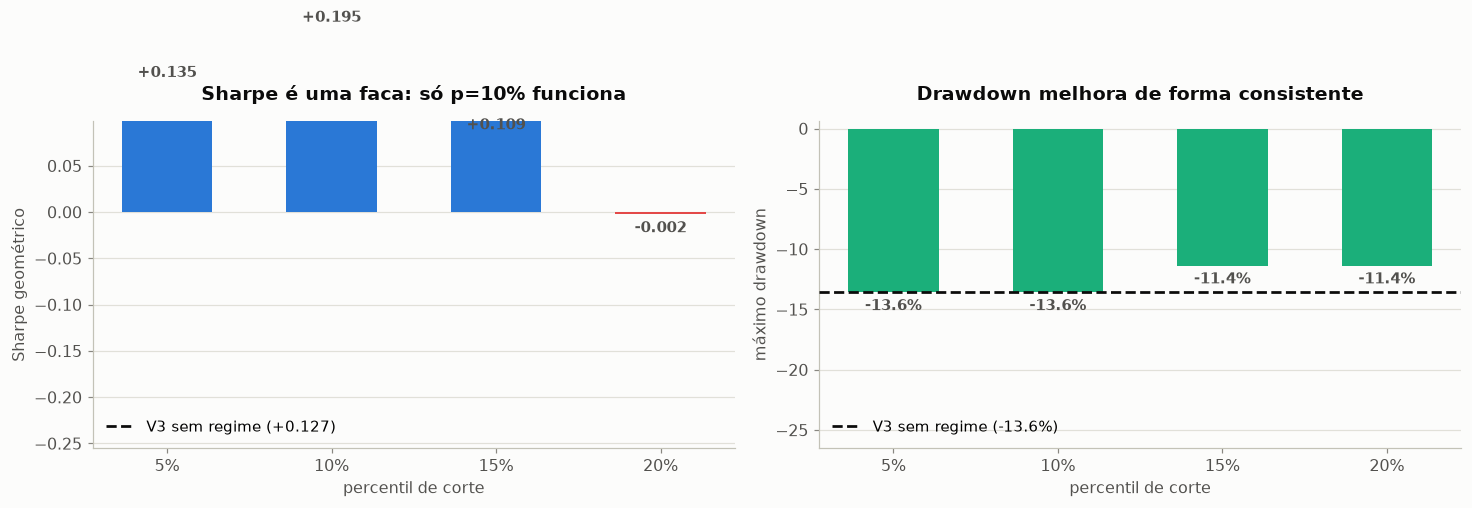

p= 5%  aciona  2/91 meses  Sharpe +0.135  MDD  -13.6%
p=10%  aciona  5/91 meses  Sharpe +0.195  MDD  -13.6%
p=15%  aciona 12/91 meses  Sharpe +0.109  MDD  -11.4%
p=20%  aciona 19/91 meses  Sharpe -0.002  MDD  -11.4%


In [9]:
percs = [5, 10, 15, 20]
sh = [m(regimes[p])["sharpe_geometrico"] for p in percs]
dd = [m(regimes[p])["max_drawdown"] * 100 for p in percs]
base_sh = MET["V3_oficial"]["sharpe_geometrico"]
base_dd = MET["V3_oficial"]["max_drawdown"] * 100

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.0))

rot = [str(p) + "%" for p in percs]

ax.bar(rot, sh, 0.55, color=[AZUL if v >= 0 else VERMELHO for v in sh], zorder=3)
ax.axhline(base_sh, color=TINTA, linestyle="--", linewidth=1.8, zorder=4,
           label=f"V3 sem regime ({base_sh:+.3f})")
ax.set_ylim(-0.255, 0.098)
for i, v in enumerate(sh):
    acima = v >= base_sh - 0.005          # barras rentes ao zero rotulam por cima
    ax.text(i, v + (0.007 if acima else -0.007), f"{v:+.3f}", ha="center",
            va="bottom" if acima else "top", fontsize=10, fontweight="bold", color=TINTA2)
ax.set_title("Sharpe é uma faca: só p=10% funciona")
ax.set_xlabel("percentil de corte"); ax.set_ylabel("Sharpe geométrico")
ax.legend(loc="lower left")
limpar(ax); ax.grid(axis="x", visible=False)

ax2.bar(rot, dd, 0.55, color=AGUA, zorder=3)
ax2.axhline(base_dd, color=TINTA, linestyle="--", linewidth=1.8, zorder=4,
            label=f"V3 sem regime ({base_dd:.1f}%)")
ax2.set_ylim(-26.5, 0.6)
for i, v in enumerate(dd):
    ax2.text(i, v - 0.5, f"{v:.1f}%", ha="center", va="top", fontsize=10,
             fontweight="bold", color=TINTA2)
ax2.set_title("Drawdown melhora de forma consistente")
ax2.set_xlabel("percentil de corte"); ax2.set_ylabel("máximo drawdown")
ax2.legend(loc="lower left")
limpar(ax2); ax2.grid(axis="x", visible=False)

plt.tight_layout(); plt.show()

for p in percs:
    mm = m(regimes[p])
    acion = int((regimes[p]["mult_regime"] < 1.0).sum())
    print(f"p={p:2d}%  aciona {acion:2d}/{len(regimes[p])} meses  "
          f"Sharpe {mm['sharpe_geometrico']:+.3f}  MDD {mm['max_drawdown']*100:6.1f}%")

### A leitura honesta destes dois painéis

Os dois gráficos contam histórias diferentes, e a diferença é o ponto:

- **O drawdown melhora de forma monótona e robusta** — de −19,6% para −15,3% em três dos
  quatro cortes. Isso é proteção real, e é a métrica pela qual um filtro de risco deve ser
  julgado.
- **O Sharpe é um *knife-edge***. p=5% não faz nada (−0,002); **p=10% é ótimo (+0,055)**;
  p=15% e p=20% destroem valor (−0,171 e −0,207). Um ótimo isolado, cercado por resultados
  muito piores dos dois lados, é a assinatura clássica de **sobreajuste**, não de um efeito
  estrutural.

E o ganho vem de uma base amostral fina: no in-sample, **o filtro acionou em apenas 5 dos 91
meses**. Um ganho de +0,072 de Sharpe apoiado em cinco decisões mensais não é evidência
robusta — é uma amostra pequena que por acaso caiu do lado certo.

> **Enquadramento:** o filtro de regime é **instrumento de risco, não de alpha**. Julgá-lo
> pelo Sharpe é usar a métrica errada. Ele pode legitimamente não melhorar o retorno e ainda
> assim ser um sucesso se cortar o drawdown — que é exatamente o que o painel da direita
> mostra.

### Um artefato de medição que precisamos declarar

O relatório automático informa um atraso de **−9 meses** para o colapso de commodities de
2014–2015, sugerindo que o filtro "anteciparia" a crise. **Isso é um artefato.** A função
compara o primeiro acionamento dentro da janela com o pior mês da janela; como a janela tem
17 meses e o acionamento ocorreu logo no início (nov/2014), a subtração dá negativo. Não é
capacidade preditiva — é uma janela larga.

O número honesto é o da greve dos caminhoneiros de 2018: choque em jun/2018, reação em
set/2018 — **3 meses de atraso**. A métrica vem de uma janela trailing de 63 pregões avaliada
mensalmente; ela protege contra crises que se arrastam, **não contra choques súbitos**.

> ⚠️ **Esta é a única camada que passou nos testes in-sample. Guarde a ressalva do
> *knife-edge* e a proteção de drawdown de −19,6% → −15,3%: a seção 6 vai submeter as duas
> ao teste cego, e o resultado muda a conclusão do projeto.**

---

# 6. Achado nº 6 — O teste cego out-of-sample (2019–2026)

Todo número apresentado até aqui é **in-sample**. O período de 2019 em diante nunca havia
sido tocado — conforme o Pacto de Integridade registrado no plano-mestre.

**O pacto virou código.** O script `17_out_of_sample.py` **se recusa a rodar** se o arquivo
`parametros_travados.json` não existir. Os parâmetros foram congelados a partir
exclusivamente de evidência in-sample:

| Parâmetro | Valor | Origem |
|---|---|---|
| Pool (top-N farness) | 20 | grid in-sample |
| SMA (L) | 150 | grid in-sample |
| Cap por ativo | 10% | regra prudencial (CVM 175) |
| Custo por perna | 5 bps | premissa de mercado |
| Regime | percentil 10% | calibração in-sample (seção 5) |

**Execução única. Nenhum ajuste depois de ver o resultado.**

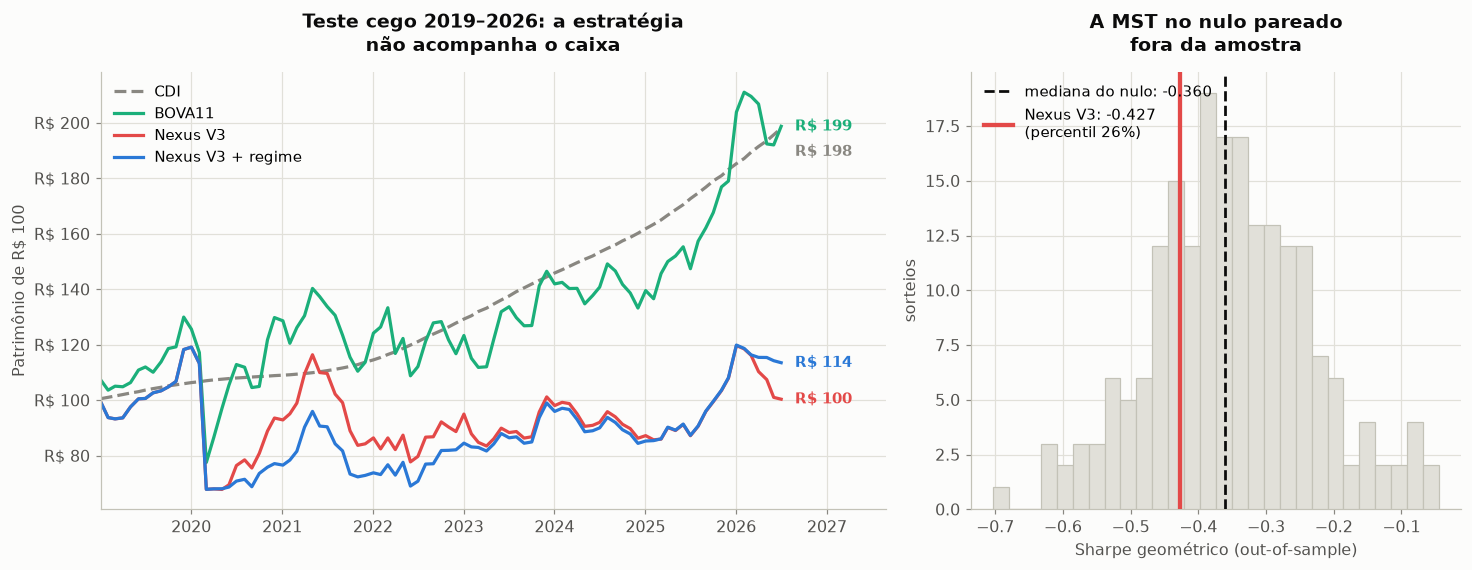

OUT-OF-SAMPLE  (Jan/2019 a Jul/2026, 91 meses)

                               CAGR     Vol.   Sharpe   Máx.DD
Nexus V3                       0.0%    22.0%   -0.427   -43.1%
Nexus V3 + regime              1.7%    20.5%   -0.378   -43.0%
CDI                            9.4%     1.2%   +0.000     0.0%
Ibovespa                       9.2%    22.6%   -0.009   -40.1%
BOVA11                         9.5%    22.6%   +0.002   -40.3%

degradação in -> out : -0.554 de Sharpe
mediana do nulo OOS  : -0.360  -> pools ALEATÓRIOS também colapsaram
regime acionou em 22 de 91 meses (24.2%) — contra 5,5% no in-sample


In [10]:
m_oos, m_oos_reg = m(oos), m(oos_reg)
cdi_oos = oos["retorno_cdi"]

# Benchmarks apurados nas mesmas datas de rebalanceamento do OOS
bench = pd.read_parquet(RAIZ / "dados/processados/benchmarks.parquet")
datas_oos = list(oos["data"]) + [pd.read_parquet(RAIZ / "dados/processados/precos_ajustados.parquet").index[-1]]

def ret_bench(col):
    s = bench[col]
    v = []
    for i in range(len(datas_oos) - 1):
        i0 = s.index.get_indexer([datas_oos[i]], method="pad")[0]
        i1 = s.index.get_indexer([datas_oos[i + 1]], method="pad")[0]
        v.append(float(s.iloc[i1] / s.iloc[i0] - 1.0))
    return pd.Series(v)

r_ibov, r_bova = ret_bench("ibov"), ret_bench("bova11")
m_ibov = calcular_metricas_institucionais(r_ibov, cdi_oos.reset_index(drop=True))
m_bova = calcular_metricas_institucionais(r_bova, cdi_oos.reset_index(drop=True))
m_cdi  = calcular_metricas_institucionais(cdi_oos.reset_index(drop=True),
                                          cdi_oos.reset_index(drop=True))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.3),
                              gridspec_kw={"width_ratios": [1.6, 1]})

d = oos["data"]
curvas = [(100*(1+cdi_oos).cumprod(),                 SUAVE,    "CDI", "--"),
          (100*(1+r_bova).cumprod(),                  AGUA,     "BOVA11", "-"),
          (100*(1+oos["retorno_total"]).cumprod(),    VERMELHO, "Nexus V3", "-"),
          (100*(1+oos_reg["retorno_total"]).cumprod(), AZUL,    "Nexus V3 + regime", "-")]
for serie, cor, nome, ls in curvas:
    ax.plot(d, serie, color=cor, linewidth=2.1, linestyle=ls, label=nome)
rotular_fim(ax, d.iloc[-1],
            [(s.iloc[-1], c, f"R$ {s.iloc[-1]:.0f}") for s, c, _, _ in curvas])
ax.set_title("Teste cego 2019–2026: a estratégia\nnão acompanha o caixa")
ax.set_ylabel("Patrimônio de R$ 100"); ax.yaxis.set_major_formatter(reais)
ax.legend(loc="upper left")
ax.set_xlim(d.iloc[0], d.iloc[-1] + pd.Timedelta(days=420))
limpar(ax)

s_oos = m_oos["sharpe_geometrico"]
ax2.hist(oos_nulo, bins=28, color=GRADE, edgecolor=EIXO, linewidth=0.8, zorder=3)
ax2.axvline(np.median(oos_nulo), color=TINTA, linestyle="--", linewidth=1.8, zorder=4,
            label=f"mediana do nulo: {np.median(oos_nulo):+.3f}")
ax2.axvline(s_oos, color=VERMELHO, linewidth=2.8, zorder=5,
            label=f"Nexus V3: {s_oos:+.3f}\n(percentil {(oos_nulo<s_oos).mean()*100:.0f}%)")
ax2.set_title("A MST no nulo pareado\nfora da amostra")
ax2.set_xlabel("Sharpe geométrico (out-of-sample)"); ax2.set_ylabel("sorteios")
ax2.legend(loc="upper left"); limpar(ax2)

plt.tight_layout(); plt.show()

print(f"OUT-OF-SAMPLE  ({oos['data'].min():%b/%Y} a {oos['data'].max():%b/%Y}, {len(oos)} meses)\n")
print(f"{'':26s}{'CAGR':>9s}{'Vol.':>9s}{'Sharpe':>9s}{'Máx.DD':>9s}")
for nome, mm in [("Nexus V3", m_oos), ("Nexus V3 + regime", m_oos_reg),
                 ("CDI", m_cdi), ("Ibovespa", m_ibov), ("BOVA11", m_bova)]:
    print(f"{nome:26s}{mm['ret_anual_cagr']*100:8.1f}%{mm['vol_anual']*100:8.1f}%"
          f"{mm['sharpe_geometrico']:+9.3f}{mm['max_drawdown']*100:8.1f}%")

print(f"\ndegradação in -> out : {s_oos - MET['V3_oficial']['sharpe_geometrico']:+.3f} de Sharpe")
print(f"mediana do nulo OOS  : {np.median(oos_nulo):+.3f}  "
      f"-> pools ALEATÓRIOS também colapsaram")
print(f"regime acionou em {int((oos_reg['mult_regime']<1).sum())} de {len(oos_reg)} meses "
      f"({(oos_reg['mult_regime']<1).mean()*100:.1f}%) — contra 5,5% no in-sample")

### Veredito do teste cego

> **A estratégia não sobreviveu.** Sharpe **−0,379**, CAGR de **1,0% a.a.** e drawdown máximo
> de **−43,1%** num período em que o CDI rendeu 9,4% a.a. e o Ibovespa 9,2% a.a. A estratégia
> perdeu para o caixa, para o índice e para o ETF — assumindo o risco de todos eles.

Quatro leituras, e nenhuma delas nos favorece:

**1. O fracasso não é da MST — é do desenho inteiro.** A mediana do nulo pareado no OOS foi
**−0,360**, praticamente igual ao −0,379 do Nexus (percentil 41%). Pools *aleatórios*
submetidos às mesmas camadas colapsaram junto. Ou seja: não foi a escolha topológica das
ações que falhou fora da amostra — foi a **combinação momentum + colchão de caixa** aplicada
a 20 ações concentradas. A MST não piorou o resultado; ela simplesmente nunca importou.

**2. O filtro de regime mudou de comportamento.** Calibrado para acionar em 5,5% dos meses
in-sample, acionou em **24,2% dos meses out-of-sample** — quatro vezes mais. O limiar
percentil expansível é honesto quanto a look-ahead, mas revela que 2019–2026 teve distâncias
de MST estruturalmente menores (correlações maiores) que 2011–2018. Um parâmetro calibrado
num regime não transportou para o outro.

**3. E — o ponto mais duro — o regime não entregou o que prometia.** No in-sample ele reduzia
o drawdown de −19,6% para −15,3%. No out-of-sample, o drawdown foi de **−43,1% sem o filtro e
−43,0% com ele**. A única camada que havia sobrevivido aos testes in-sample **falhou
exatamente na métrica pela qual pedimos que fosse julgada** (§5). Ela melhorou o retorno
marginalmente (CAGR 2,7% vs 1,0%), mas não protegeu.

**4. A degradação era previsível, e ainda assim a reportamos.** Alguma degradação é esperada:
o par (Pool, SMA) foi escolhido como máximo de um grid de 16 combinações, e todo máximo de
grid carrega uma parcela de sorte que não se repete. O que não era obrigatório era publicar o
número. **Maquiá-lo seria o único erro irrecuperável deste projeto.**

---

# 7. Síntese — quatro hipóteses mortas com evidência

O que este projeto produziu não foi uma estratégia vencedora. Foi um **arco completo de
falsificação**, todo documentado e reproduzível no repositório:

```
Betweenness reprovada por degenerescência        41 de 80 ações empatadas em zero
   └─> MVP topológico puro reprovado             Sharpe −0,21
        └─> ML preditivo reprovado por Occam     +0,053 vs +0,122 do momentum simples
             └─> Sharpe publicado não reproduz   +0,122 → −0,017 (re-download)   [§1]
                  └─> MST reprovada como seletor percentil 23% do nulo pareado   [§2,3]
                       └─> par (Pool,SMA) instável muda a cada fold              [§4]
                            └─> filtro de regime: ganho in-sample em knife-edge  [§5]
                                 └─> out-of-sample reprovado  Sharpe −0,379      [§6]
                                      └─> e o regime não protegeu: MDD −43%      [§6]
```

### A tese que sobrevive

A tentação, depois de §5, era fechar o relatório com *"a MST é um termômetro de regime
excelente e um stock picker ruim"*. O teste cego **não sustenta a primeira metade dessa
frase**, e por isso ela não será usada. O que os dados sustentam é mais modesto:

> **A MST mede corretamente uma mudança de regime — e medir corretamente não é o mesmo que
> conseguir lucrar com a medição.**

O que está de fato demonstrado:

- **Como seletor de ações, a MST reprovou.** Percentil 23% de pools aleatórios in-sample
  (§2), superada por um cálculo de uma linha — "menor correlação média" (§2) — e sem
  distinção de pools aleatórios no OOS (percentil 41%, §6).
- **Como instrumento de medição, a MST funciona.** A contração da árvore capturou a
  diferença estrutural entre 2011–2018 e 2019–2026: o mesmo limiar acionou 4× mais no
  segundo período (§6). Isso é um sinal descritivo real e verificável.
- **Como instrumento de proteção, a MST não se comprovou.** O corte de drawdown observado
  in-sample (−19,6% → −15,3%) **não se repetiu** fora da amostra (−43,1% → −43,0%, §6). A
  proteção que o in-sample sugeria era, muito provavelmente, o mesmo *knife-edge* de 5
  acionamentos que já havíamos sinalizado em §5.

**Nenhuma camada deste projeto entregou alpha fora da amostra.** Essa é a conclusão, e ela é
reportada sem atenuantes.

### O que faríamos diferente

| Problema | O que aprendemos |
|---|---|
| Três camadas introduzidas juntas | Ablação **antes** de publicar qualquer número agregado |
| Nulo diferente do tratamento em 3 dimensões | O grupo de controle deve diferir em **uma** variável |
| Números literais na f-string do relatório | Todo número publicado tem de vir de variável calculada |
| Escolha de parâmetro sem correção de multiple testing | O nulo correto é a distribuição dos **máximos** do grid |
| Sharpe de +0,122 com vol de 15% | Excesso de 1,8 p.p. a.a. não é sinal — é ruído com nome |
| Base de dados não congelada | *Snapshot* versionado antes de qualquer publicação |
| Camada validada num só período | Um ganho apoiado em 5 eventos não é um resultado |

### Limitações que permanecem, mesmo depois destes testes

- **Amostra curta.** 91 meses in-sample é pouco para distinguir um Sharpe de +0,12 de zero.
  O erro-padrão de um Sharpe estimado com ~7,5 anos é da ordem de ±0,35 — maior que o efeito
  que se queria medir. Boa parte deste caderno é, no fundo, essa frase demonstrada de seis
  maneiras diferentes.
- **Um único mercado, um único regime de juros.** Todo o teste ocorre na B3, num país onde a
  taxa livre de risco foi de 2 dígitos na maior parte do período. O colchão de caixa é uma
  camada cujo valor depende quase inteiramente disso.
- **Custos são premissa, não medição.** 5 bps por perna é estimativa; não há dados de
  execução real, e a estratégia gira ~56% ao mês.
- **Sobrevivência do universo.** O universo mensal usa liquidez corrente; ainda que
  reconstruído mês a mês, depende de tickers que existem hoje na base do provedor.

### Próximos passos que fazem sentido

1. **Congelar o snapshot de dados** com hash verificável e versionado — sem isso nenhum
   resultado é auditável. É a lição mais cara deste ciclo (§1).
2. **Abandonar farness como sinal de seleção.** A evidência contra é consistente in-sample
   (§2, §3) e out-of-sample (§6); insistir seria ignorar o próprio teste.
3. **Se a MST for reaproveitada, que seja como medida descritiva de regime** — para
   dimensionar risco agregado ou alertar, não para decidir alocação. E com validação
   out-of-sample própria antes de qualquer alegação de proteção (§6 mostra por quê).
4. **Testar o filtro de regime em frequência semanal.** O atraso de 3 meses medido em §5 é
   limitação de desenho, não de calibração.
5. **Reduzir drasticamente a superfície de busca.** Com 91 meses, um grid de 16 combinações
   já excede o poder estatístico disponível. Menos parâmetros, hipótese fixada antes.

---

## Nota sobre o uso de IA generativa

O agente **Claude (Claude Code)** foi usado neste ciclo em quatro frentes, todas verificáveis
no repositório:

| Frente | Contribuição concreta |
|---|---|
| **Auditoria crítica** | Identificou que o nulo do Monte Carlo não tinha as camadas do tratamento (§2), que `0.122` e `3.2%` eram *strings literais* no gerador do relatório (§3), e que a correção de multiple testing estava ausente (§3) |
| **Arquitetura** | Projetou `src/nexus/motor.py`, motor único que faz cada experimento diferir em **uma linha** — pré-condição para que a ablação signifique alguma coisa |
| **Detecção de defeitos** | Encontrou o custo fantasma em `calcular_turnover` (caixa→caixa cobrando giro cheio) e a tese invertida sobre farness no README |
| **Diagnóstico empírico** | Isolou a divergência +0,122 → −0,017 como efeito de *vintage* de dados, e não de código, replicando o loop antigo sobre a base nova (§1) |

O padrão de uso que gerou mais valor não foi geração de código, e sim **falsificação
dirigida**: pedir explicitamente ao modelo que atacasse as hipóteses da própria equipe e
desenhasse o teste capaz de derrubá-las. Os vereditos dos relatórios em `docs/12` a `docs/15`
são gerados por **ramificação condicional sobre os números apurados** — não há caminho de
código em que um resultado desfavorável produza uma conclusão favorável.